In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv('Cleaned_data.csv')
df.head()

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Price,Quantity,Channel,City,Customer_ID,Stock_Available,Sales,Stock_Status
0,1,2024-05-10,1077,Shoes,Fashion,3610.49,2,Online,Delhi,6959,422,7220.98,Overstock
1,2,2024-12-31,1035,Shoes,Fashion,2164.15,2,Store,Delhi,5426,65,4328.30,Optimal
2,3,2024-11-10,1094,Sofa,Furniture,107.99,1,Store,Bangalore,5728,268,107.99,Optimal
3,4,2022-05-02,1027,Headphones,Electronics,1909.50,3,Store,Delhi,5880,178,5728.50,Optimal
4,5,2023-04-12,1097,Watch,Electronics,432.02,4,Store,Bangalore,5561,212,1728.08,Optimal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         20000 non-null  int64  
 1   Order_Date       20000 non-null  object 
 2   Product_ID       20000 non-null  int64  
 3   Product_Name     20000 non-null  object 
 4   Category         12458 non-null  object 
 5   Price            20000 non-null  float64
 6   Quantity         20000 non-null  int64  
 7   Channel          20000 non-null  object 
 8   City             20000 non-null  object 
 9   Customer_ID      20000 non-null  int64  
 10  Stock_Available  20000 non-null  int64  
 11  Sales            20000 non-null  float64
 12  Stock_Status     20000 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 2.0+ MB


In [4]:
df.describe()

,Order_ID,Product_ID,Price,Quantity,Customer_ID,Stock_Available,Sales
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,1049.465650,2554.060570,2.484500,5995.859250,249.780450,6346.054379
std,5773.647028,28.817338,1408.157985,1.115895,581.205845,145.016374,4769.673008
min,1.000000,1000.000000,100.040000,1.000000,5000.000000,0.000000,100.040000
25%,5000.750000,1025.000000,1348.317500,1.000000,5489.000000,124.000000,2531.942500
50%,10000.500000,1050.000000,2555.590000,2.000000,5993.000000,249.000000,4902.390000
75%,15000.250000,1074.250000,3785.065000,3.000000,6504.000000,376.000000,9294.412500
max,20000.000000,1099.000000,4999.700000,4.000000,6999.000000,499.000000,19998.800000


In [5]:
df.describe(include=object)

,Order_Date,Product_Name,Category,Channel,City,Stock_Status
count,20000,20000,12458,20000,20000,20000
unique,1096,8,3,3,4,3
top,2024-03-26,Shirt,Electronics,App,Hyderabad,Optimal
freq,31,2566,7502,6714,5044,9984


In [6]:
num = df.select_dtypes(exclude=object).columns.to_list()

In [7]:
num

['Order_ID',
 'Product_ID',
 'Price',
 'Quantity',
 'Customer_ID',
 'Stock_Available',
 'Sales']

In [8]:
cat = df.select_dtypes(include=object).columns.to_list()

In [9]:
cat

['Order_Date', 'Product_Name', 'Category', 'Channel', 'City', 'Stock_Status']

### Visualizations

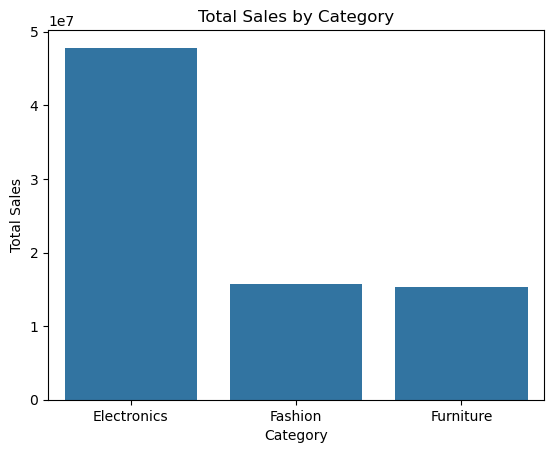

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

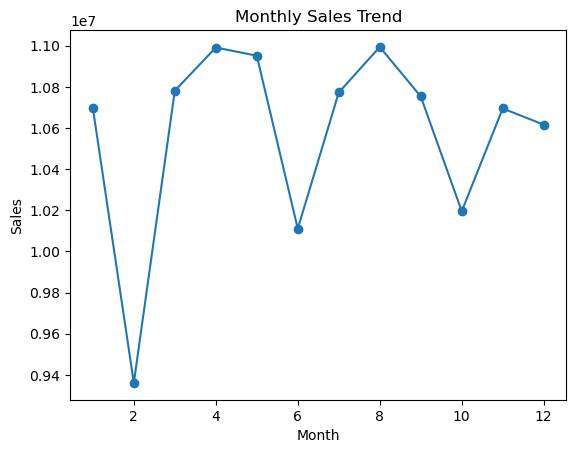

In [25]:
df['Month'] = df['Order_Date'].dt.month
df.groupby('Month')['Sales'].sum().plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

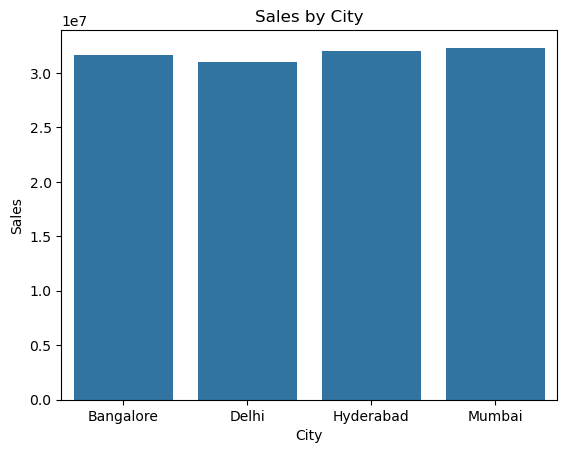

In [28]:
city_sales = df.groupby('City')['Sales'].sum()
sns.barplot(x=city_sales.index,y=city_sales.values)
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

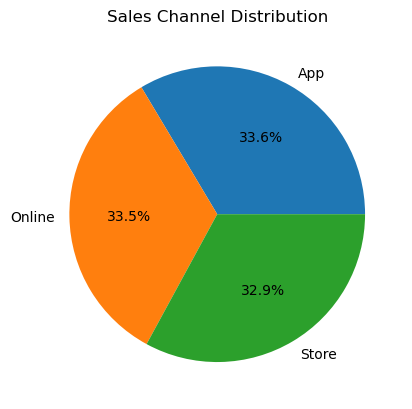

In [31]:
channel_sales = df['Channel'].value_counts()
plt.pie(channel_sales.values, labels=channel_sales.index, autopct='%1.1f%%')
plt.title("Sales Channel Distribution")
plt.show()

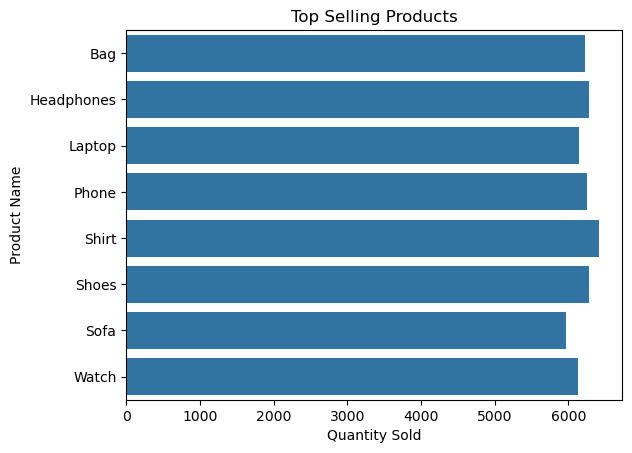

In [33]:
top_products = df.groupby('Product_Name')['Quantity'].sum()
sns.barplot(x=top_products.values,y=top_products.index)
plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")
plt.show()

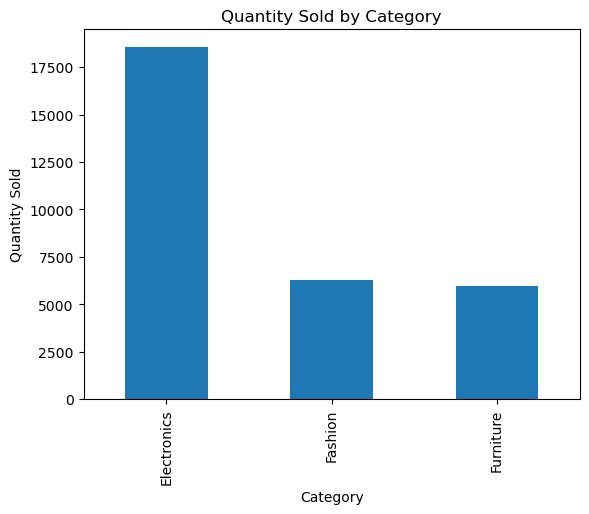

In [34]:
df.groupby('Category')['Quantity'].sum().plot(kind='bar')
plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.show()

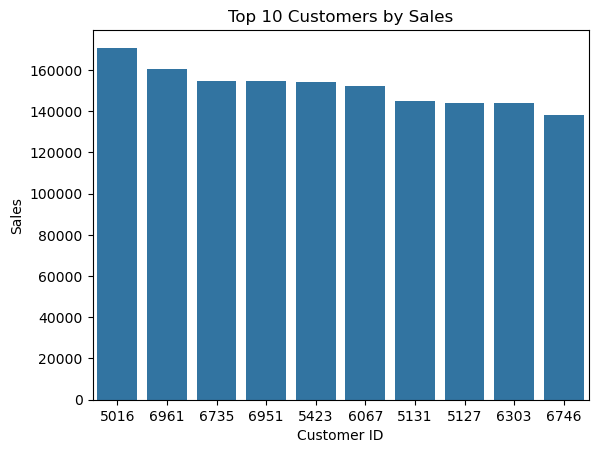

In [39]:
top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_customers.index.astype(str),y=top_customers.values)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Sales")
plt.show()

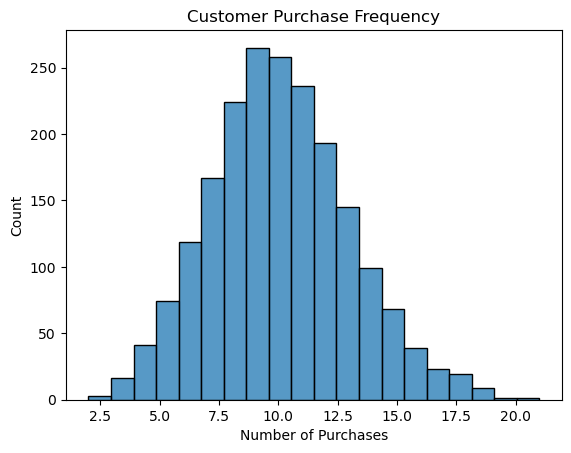

In [40]:
sns.histplot(df['Customer_ID'].value_counts(),bins=20)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.show()

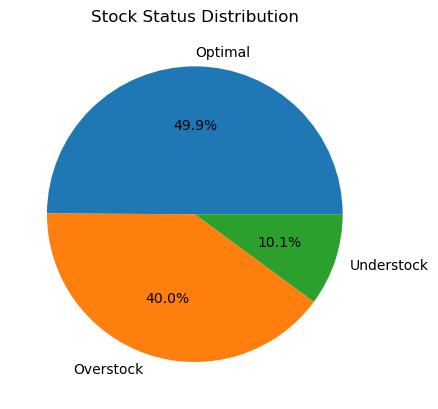

In [43]:
stock_status = df['Stock_Status'].value_counts()
plt.pie(stock_status.values,
        labels=stock_status.index,
        autopct='%1.1f%%')
plt.title("Stock Status Distribution")
plt.show()

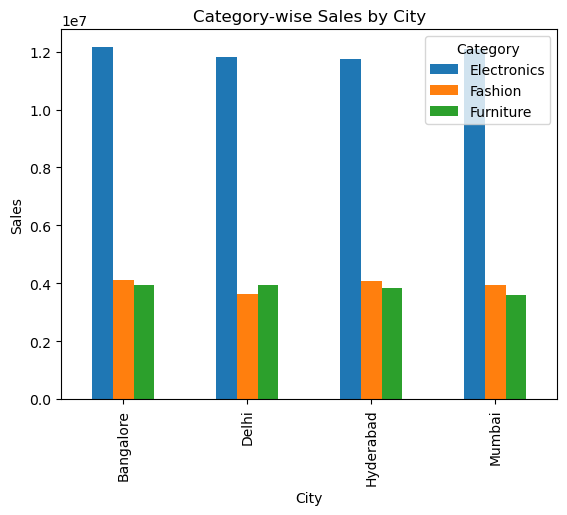

In [49]:
df.pivot_table(values='Sales',index='City',columns='Category',aggfunc='sum').plot(kind='bar')
plt.title("Category-wise Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

<Axes: >

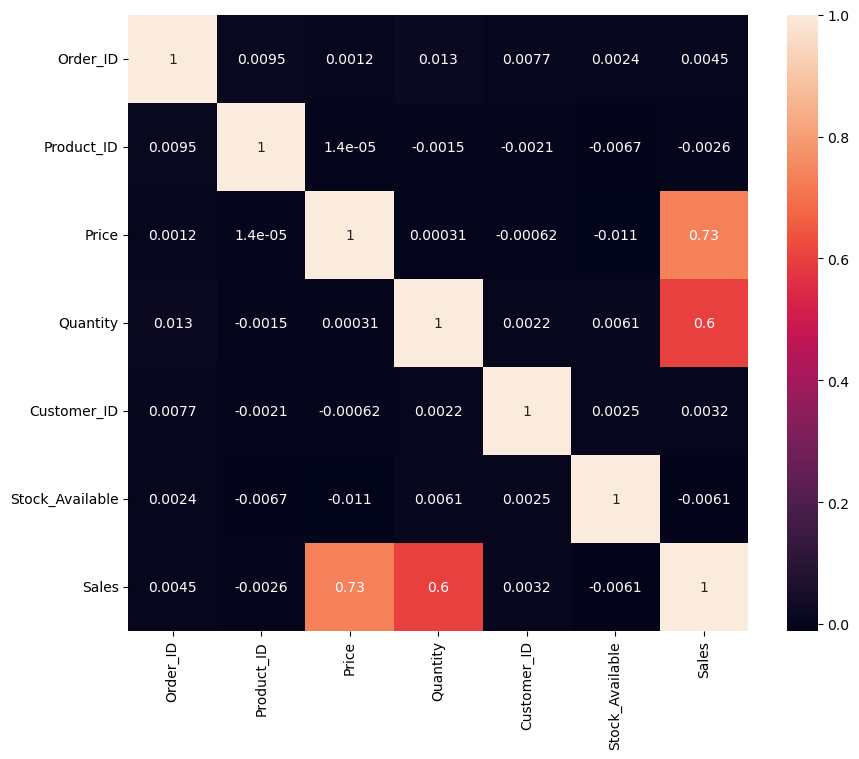

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num].corr(),annot=True)

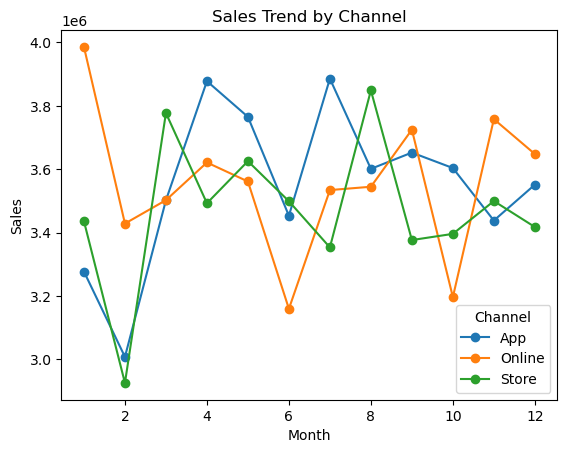

In [55]:
df.groupby(['Month', 'Channel'])['Sales'].sum().unstack().plot(marker='o')
plt.title("Sales Trend by Channel")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

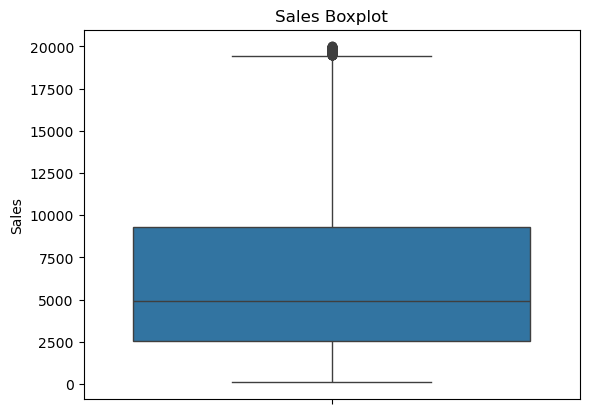

In [56]:
sns.boxplot(y=df['Sales'])
plt.title("Sales Boxplot")
plt.show()